##Libraries and Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

##Load Dataset

In [2]:
df = pd.read_csv("Term_Project_Dataset_20K.csv")
df.head()

,age,gender,parent_income,num_siblings,family_support,commute_time_min,part_time_job,previous_gpa,num_failed_courses,high_school_grade,...,concentration_level,exam_anxiety_level,course_difficulty_rating,teacher_experience_years,class_size,num_prerequisites,course_type,final_score,final_grade,pass_fail
0,24.0,Female,22678.0,0.0,1.0,95.0,No,2.22,3.0,99.7,...,7.0,6.0,2.0,11.0,95.0,3.0,Elective,NaN,C,Pass
1,21.0,Male,17905.0,3.0,2.0,0.0,Yes,3.78,1.0,75.7,...,3.0,3.0,1.0,NaN,148.0,2.0,Elective,81.7,C,Pass
2,28.0,Male,NaN,0.0,0.0,67.0,No,NaN,4.0,93.4,...,1.0,8.0,1.0,32.0,55.0,3.0,Elective,77.3,B,Pass
3,25.0,Female,29391.0,4.0,4.0,83.0,Yes,1.84,4.0,69.7,...,6.0,10.0,5.0,30.0,42.0,1.0,Mandatory,78.5,B,Pass
4,22.0,Male,15522.0,0.0,4.0,58.0,Yes,3.38,0.0,62.2,...,10.0,5.0,3.0,31.0,123.0,1.0,Mandatory,60.3,D,Pass


##Data Understanding & Exploration

In [3]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          19400 non-null  float64
 1   gender                       19400 non-null  object 
 2   parent_income                19400 non-null  float64
 3   num_siblings                 19400 non-null  float64
 4   family_support               19400 non-null  float64
 5   commute_time_min             19400 non-null  float64
 6   part_time_job                19400 non-null  object 
 7   previous_gpa                 19400 non-null  float64
 8   num_failed_courses           19400 non-null  float64
 9   high_school_grade            19400 non-null  float64
 10  math_background_score        19400 non-null  float64
 11  language_background_score    19400 non-null  float64
 12  science_background_score     19400 non-null  float64
 13  prior_semester_c

,0
age,600
gender,600
parent_income,600
num_siblings,600
family_support,600
commute_time_min,600
part_time_job,600
previous_gpa,600
num_failed_courses,600
high_school_grade,600


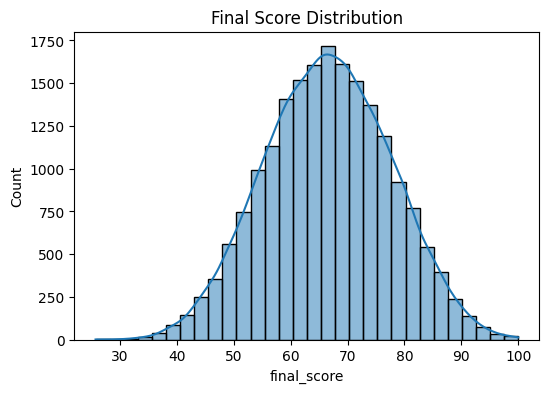

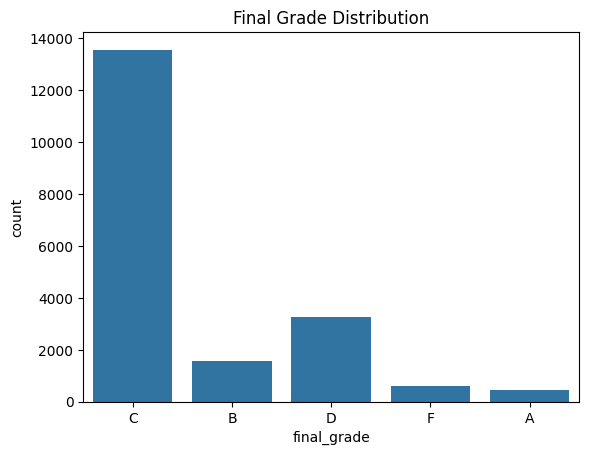

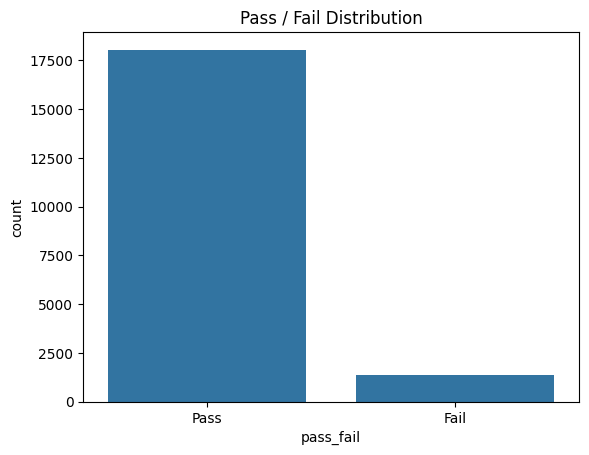

In [4]:
##Target Variable Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['final_score'], bins=30, kde=True)
plt.title("Final Score Distribution")
plt.show()

sns.countplot(x=df['final_grade'])
plt.title("Final Grade Distribution")
plt.show()

sns.countplot(x=df['pass_fail'])
plt.title("Pass / Fail Distribution")
plt.show()

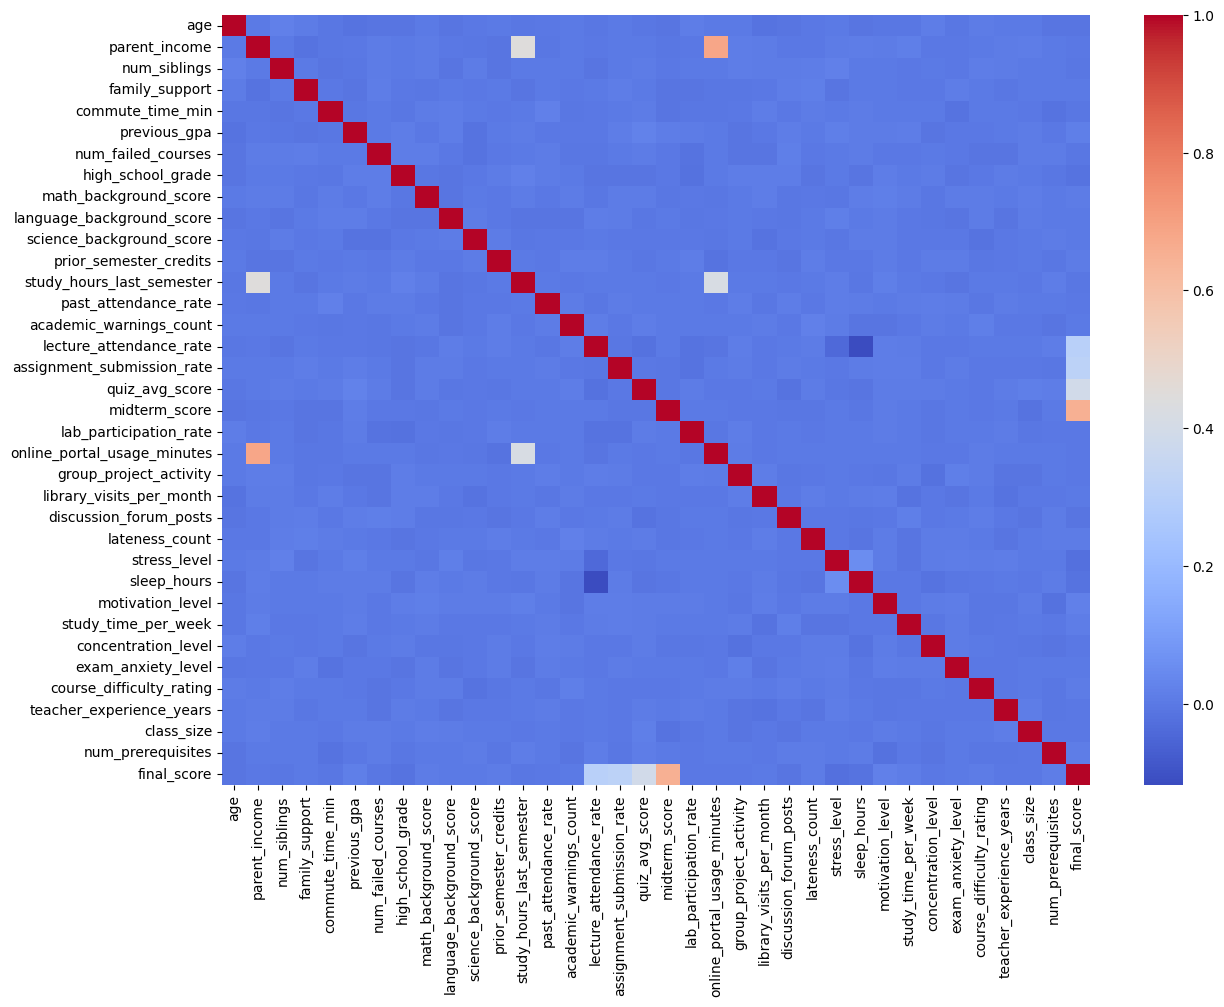

In [5]:
##Correlation Analysis
plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes(np.number).corr(), cmap='coolwarm')
plt.show()

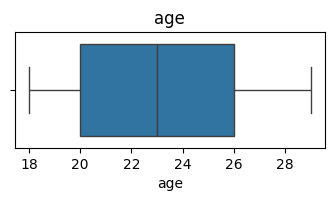

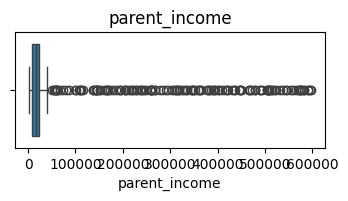

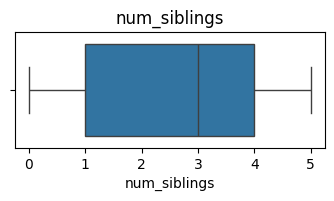

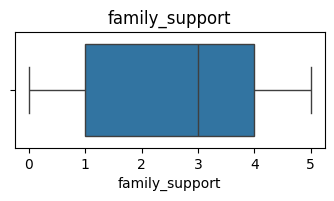

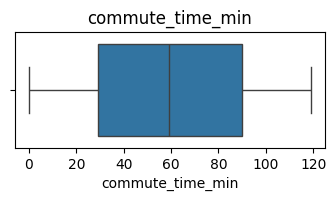

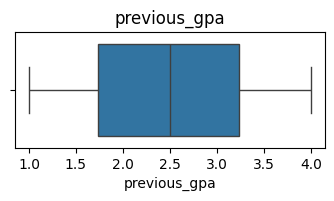

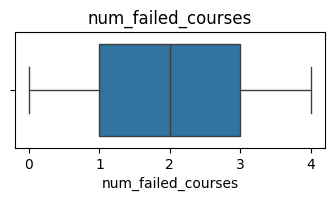

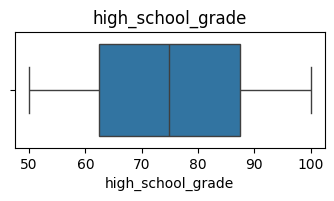

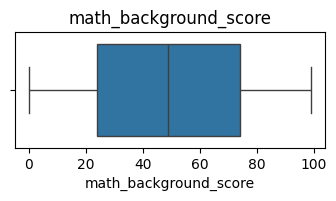

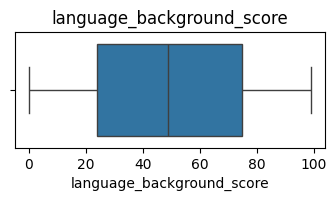

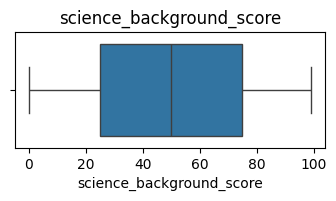

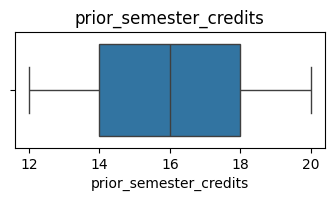

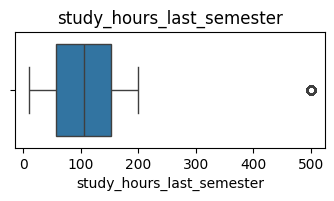

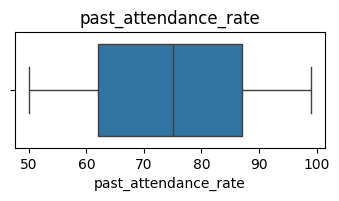

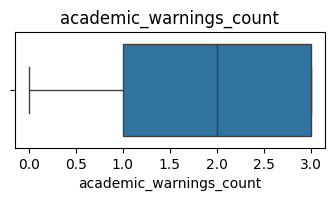

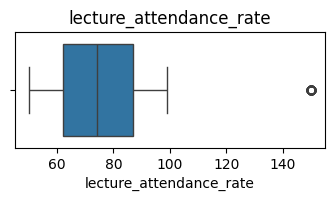

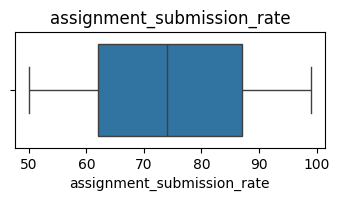

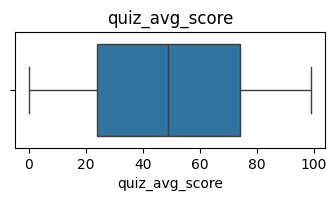

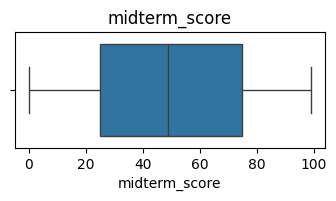

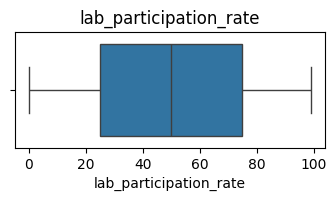

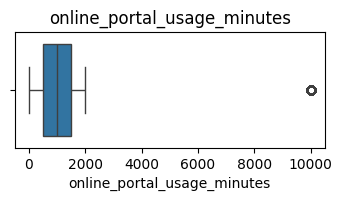

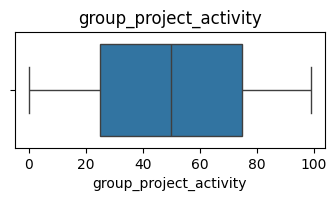

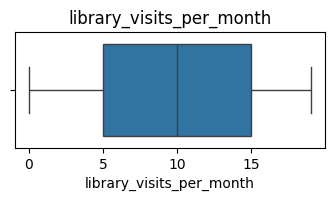

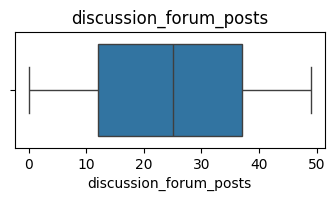

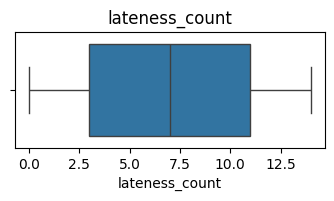

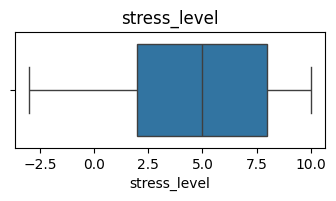

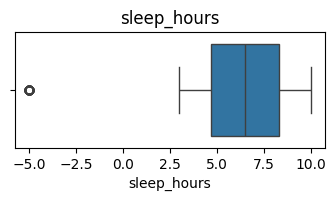

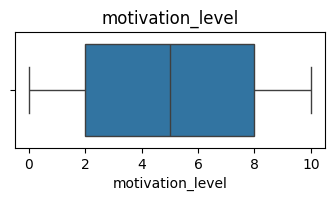

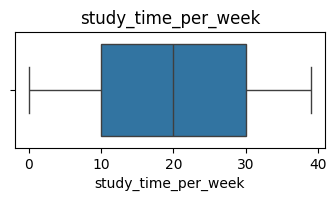

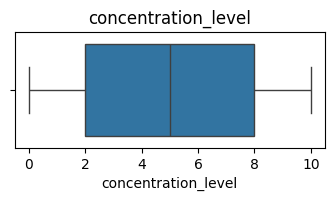

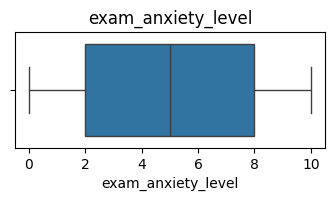

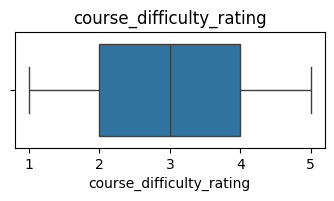

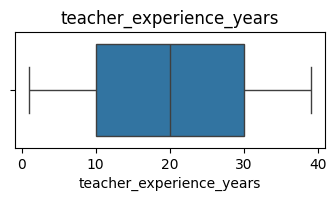

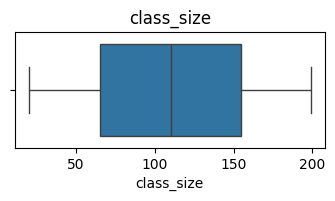

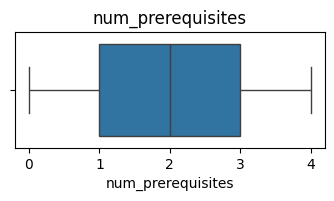

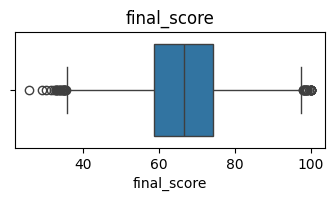

In [6]:
##Outlier Detection
for col in df.select_dtypes(include=['int64','float64']):
    plt.figure(figsize=(4,1.5))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

##Data Preprocessing

In [7]:
##Handling Missings
for col in df.select_dtypes(include=['int64','float64']):
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include=['object']):
    df[col].fillna(df[col].mode()[0], inplace=True)

##Feature Engineering

In [8]:
df['continuous_assessment_score'] = (
    0.4*df['midterm_score'] +
    0.3*df['quiz_avg_score'] +
    0.3*df['assignment_submission_rate']
)

df['engagement_score'] = (
    df['lecture_attendance_rate'] +
    df['assignment_submission_rate'] +
    df['lab_participation_rate']
) / 3

df['academic_strength'] = (
    df['previous_gpa'] +
    df['high_school_grade'] +
    df['midterm_score']
) / 3

In [9]:
##Handling Outliers
df = df[df['final_score'] <= 100]
df['study_hours_last_semester'] = df['study_hours_last_semester'].clip(
    upper=df['study_hours_last_semester'].quantile(0.99)
)

df = df[(df['sleep_hours'] >= 3) & (df['sleep_hours'] <= 14)]

Q1 = df['online_portal_usage_minutes'].quantile(0.25)
Q3 = df['online_portal_usage_minutes'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['online_portal_usage_minutes'] = df['online_portal_usage_minutes'].clip(lower=lower_bound, upper=upper_bound)

print("IQR-based capping applied to 'online_portal_usage_minutes'.")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

IQR-based capping applied to 'online_portal_usage_minutes'.
Lower Bound: -956.50
Upper Bound: 2967.50


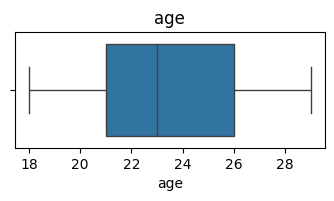

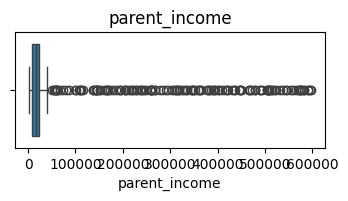

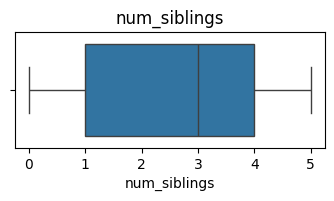

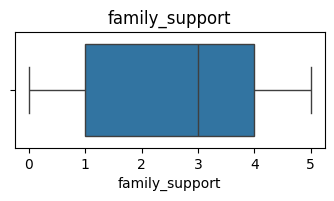

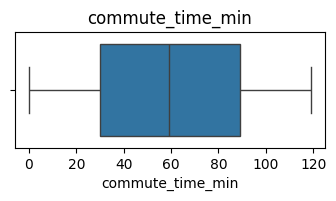

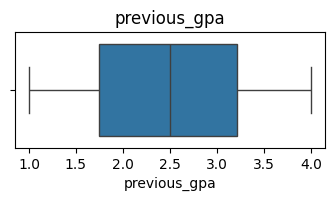

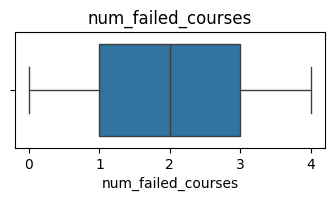

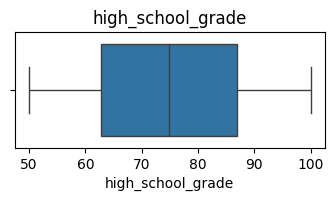

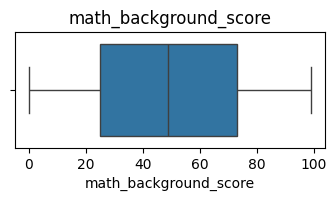

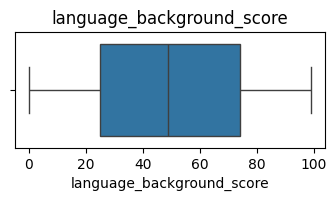

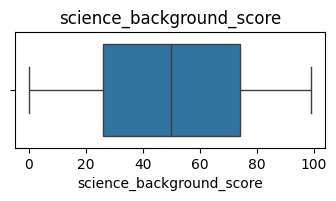

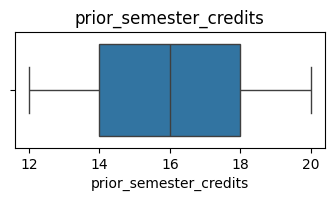

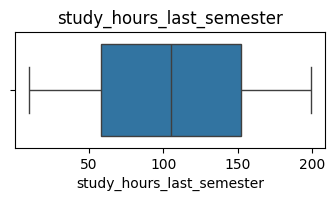

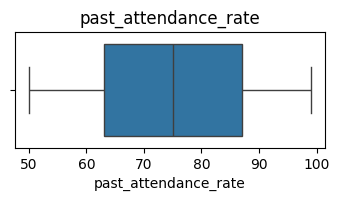

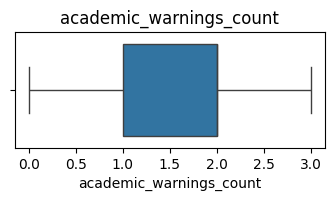

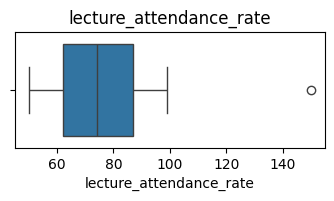

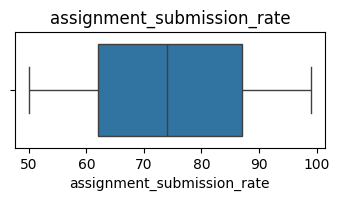

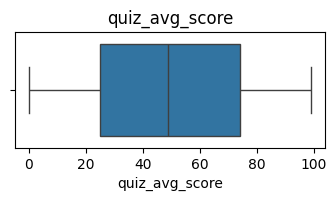

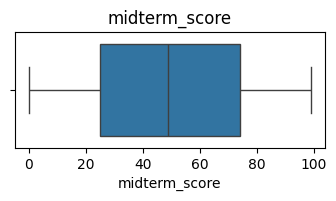

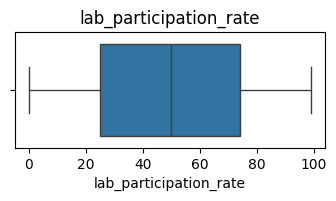

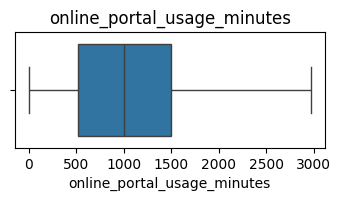

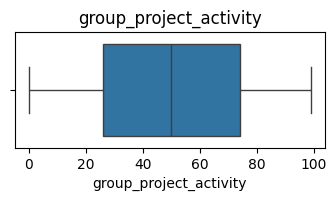

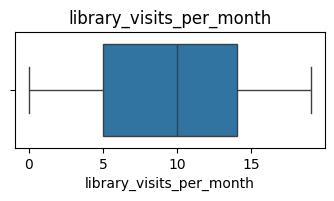

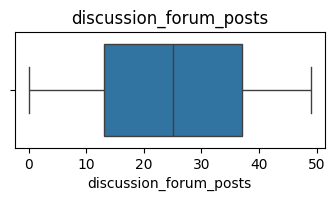

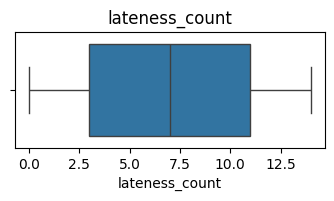

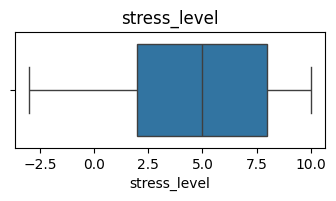

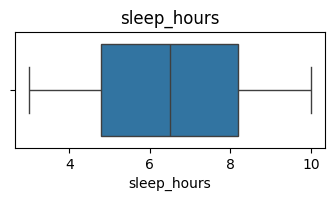

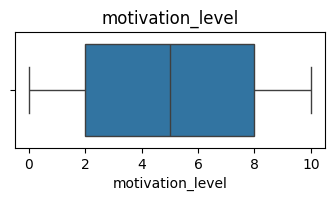

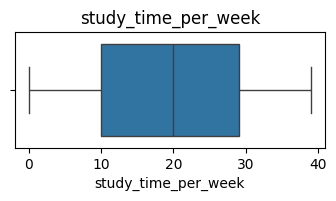

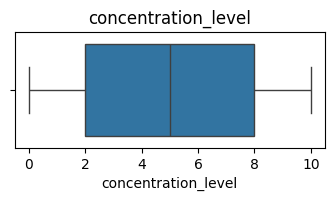

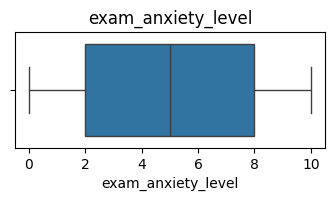

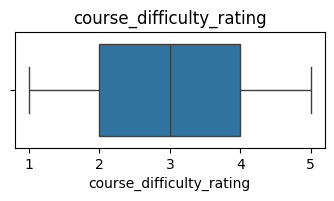

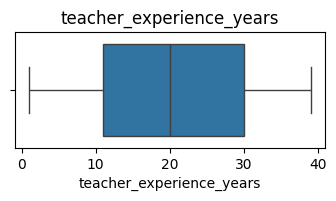

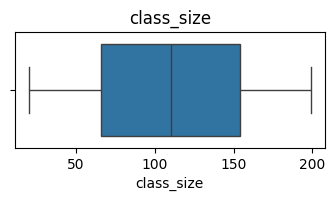

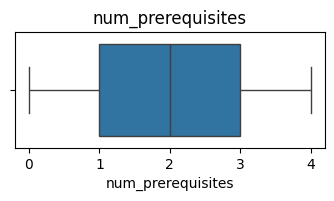

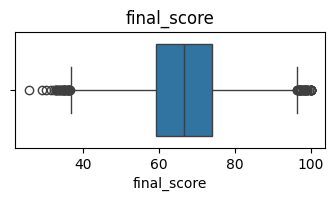

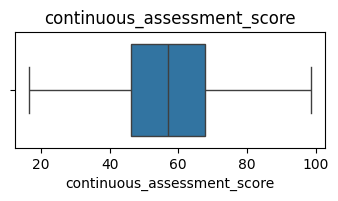

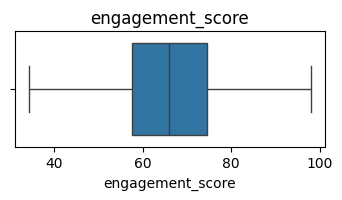

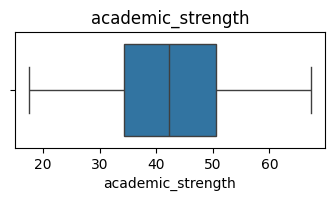

In [10]:
for col in df.select_dtypes(include=['int64','float64']):
    plt.figure(figsize=(4,1.5))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [11]:
##Categorical Encoding
df = pd.get_dummies(
    df,
    columns=['gender','part_time_job','course_type'],
    drop_first=True
)

In [12]:
##Target Encoding
from sklearn.preprocessing import LabelEncoder
#Ordinal Encoding
grade_mapping = {
    'F': 0,
    'D': 1,
    'C': 2,
    'B': 3,
    'A': 4
}

y_grade = df['final_grade'].map(grade_mapping)

#Label Encoding
le = LabelEncoder()
y_pass = le.fit_transform(df['pass_fail'])


In [13]:
X = df.drop(columns=['final_score','final_grade','pass_fail'])
y_reg = df['final_score']
y_bin = y_pass
y_multi = y_grade

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
##Train, Validation, and Test Split
X_train, X_temp, y_train_reg, y_temp_reg, y_train_bin, y_temp_bin, y_train_multi, y_temp_multi = train_test_split(
    X_scaled, y_reg, y_bin, y_multi,
    test_size=0.3, stratify=y_bin, random_state=42
)

X_val, X_test, y_val_reg, y_test_reg, y_val_bin, y_test_bin, y_val_multi, y_test_multi = train_test_split(
    X_temp, y_temp_reg, y_temp_bin, y_temp_multi,
    test_size=0.5, stratify=y_temp_bin, random_state=42
)

##Regression Models – Final Score Prediction




Linear
MSE: 30.111531001397488
MAE: 4.30933386616462
R2 : 0.7525498256400232


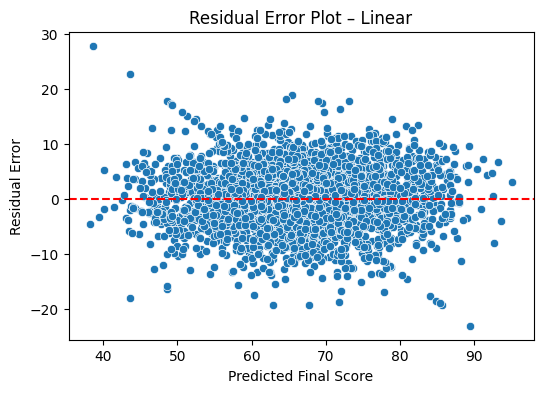


Ridge
MSE: 30.111594806221603
MAE: 4.30935093180324
R2 : 0.7525493013055131


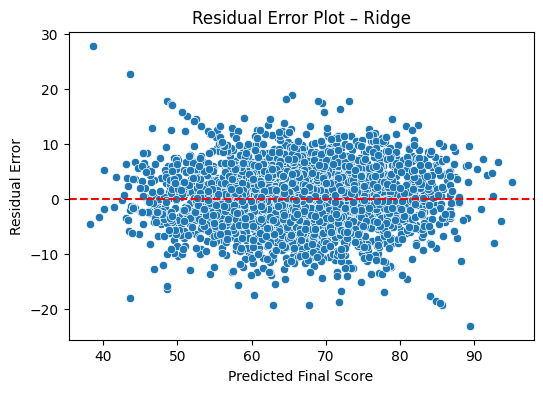


Lasso
MSE: 30.094749979997694
MAE: 4.308340752212554
R2 : 0.752687728514212


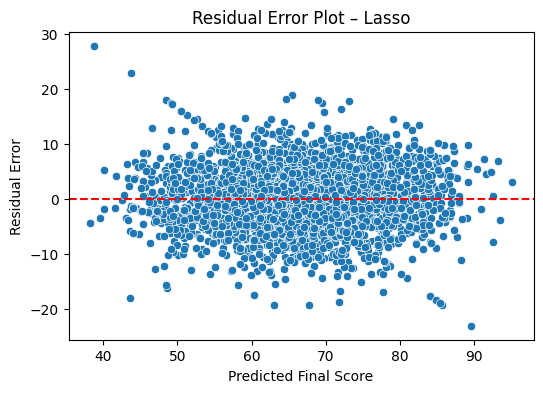


Random Forest
MSE: 31.617200301623168
MAE: 4.424370314591701
R2 : 0.7401765547209185


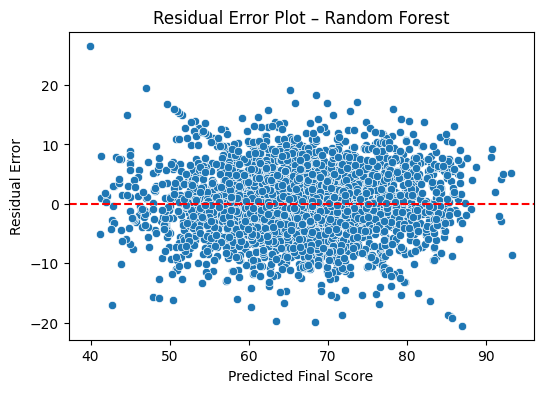


Gradient Boosting
MSE: 30.710196171978165
MAE: 4.357605020758782
R2 : 0.7476301222600602


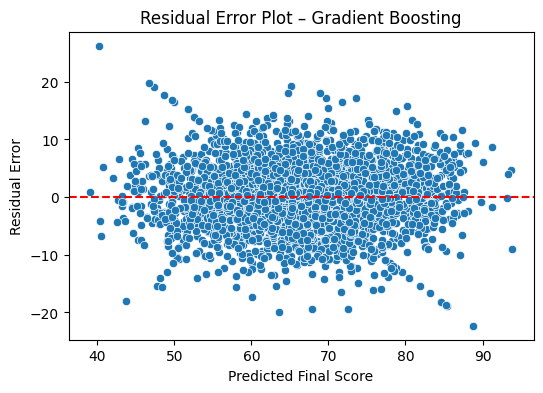

In [15]:
reg_models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1),
    "Lasso": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

for name, model in reg_models.items():
    model.fit(X_train, y_train_reg)
    preds = model.predict(X_val)

    print(f"\n{name}")
    print("MSE:", mean_squared_error(y_val_reg, preds))
    print("MAE:", mean_absolute_error(y_val_reg, preds))
    print("R2 :", r2_score(y_val_reg, preds))

    residuals = y_val_reg - preds

    plt.figure(figsize=(6,4))
    sns.scatterplot(x=preds, y=residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted Final Score")
    plt.ylabel("Residual Error")
    plt.title(f"Residual Error Plot – {name}")
    plt.show()

##Binary Classification – Pass / Fail Prediction

In [16]:
knn = KNeighborsClassifier(
    n_neighbors=12,
    weights='distance'
)
knn.fit(X_train, y_train_bin)

pred = knn.predict(X_val)
prob = knn.predict_proba(X_val)[:, 1]

print("KNN Accuracy :", accuracy_score(y_val_bin, pred))
print("Precision    :", precision_score(y_val_bin, pred, pos_label=1))
print("Recall       :", recall_score(y_val_bin, pred, pos_label=1))
print("F1           :", f1_score(y_val_bin, pred, pos_label=1))
print("ROC AUC      :", roc_auc_score(y_val_bin, prob))

KNN Accuracy : 0.9344042838018741
Precision    : 0.936026936026936
Recall       : 0.9978463747307968
F1           : 0.965948575399583
ROC AUC      : 0.8613283887613457


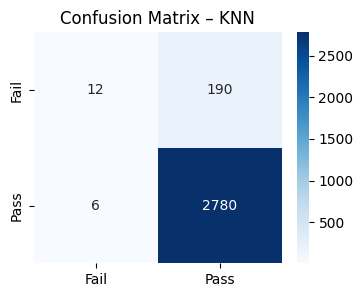

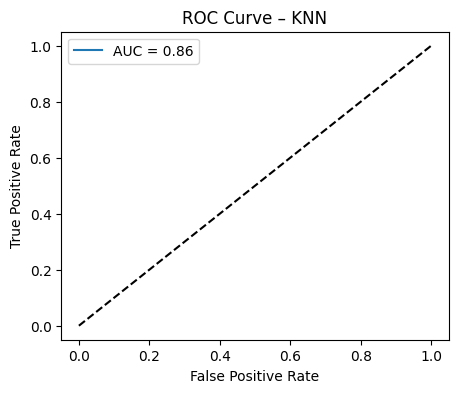

In [17]:
##Confusion Matrix & ROC Curve

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val_bin, pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=['Fail','Pass'],
yticklabels=['Fail','Pass'])
plt.title('Confusion Matrix – KNN')
plt.show()


fpr, tpr, _ = roc_curve(y_val_bin, prob, pos_label='Pass')
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_val_bin, prob):.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – KNN')
plt.legend()
plt.show()


Logistic
Accuracy : 0.8768406961178046
Precision: 0.9906655844155844
Recall   : 0.8761665470208184
F1       : 0.9299047619047619
ROC AUC  : 0.9530129430746377


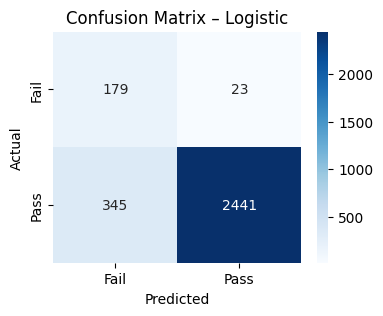


Decision Tree
Accuracy : 0.8972556894243642
Precision: 0.9658023299511462
Recall   : 0.9224694903086863
F1       : 0.9436387002019461
ROC AUC  : 0.7359872204018679


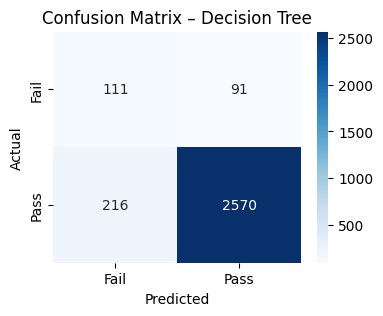


Random Forest
Accuracy : 0.9354082998661312
Precision: 0.9692363373145132
Recall   : 0.9612347451543432
F1       : 0.9652189583708777
ROC AUC  : 0.9373449638574769


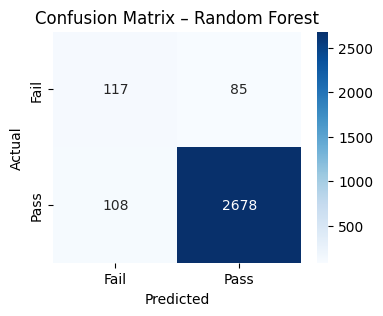


SVM
Accuracy : 0.928380187416332
Precision: 0.9700292397660819
Recall   : 0.9526202440775305
F1       : 0.9612459253893517
ROC AUC  : 0.9298987867200216


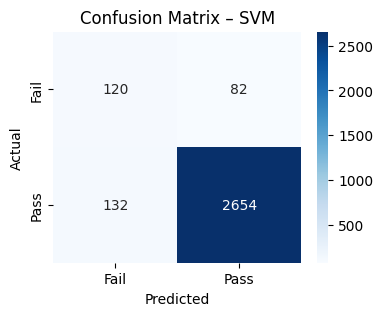

In [18]:
##Class Imbalance Handling
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train_bin)

bin_models = {
    "Logistic": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42
    ),
    "SVM": SVC(class_weight='balanced', probability=True)
}

for name, model in bin_models.items():
    model.fit(X_train_sm, y_train_sm)

    pred = model.predict(X_val)
    prob = model.predict_proba(X_val)[:,1]

    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_val_bin, pred))
    print("Precision:", precision_score(y_val_bin, pred, pos_label=1))
    print("Recall   :", recall_score(y_val_bin, pred, pos_label=1))
    print("F1       :", f1_score(y_val_bin, pred, pos_label=1))
    print("ROC AUC  :", roc_auc_score(y_val_bin, prob))

    # Confusion Matrix
    cm = confusion_matrix(y_val_bin, pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Fail','Pass'],
        yticklabels=['Fail','Pass']
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix – {name}")
    plt.show()

##Multi-Class Classification – Final Grade Prediction


Logistic
Accuracy: 0.42971887550200805
              precision    recall  f1-score   support

           0       0.19      0.78      0.30        90
           1       0.30      0.49      0.38       465
           2       0.82      0.37      0.51      2117
           3       0.21      0.58      0.31       236
           4       0.24      0.76      0.36        80

    accuracy                           0.43      2988
   macro avg       0.35      0.60      0.37      2988
weighted avg       0.66      0.43      0.46      2988



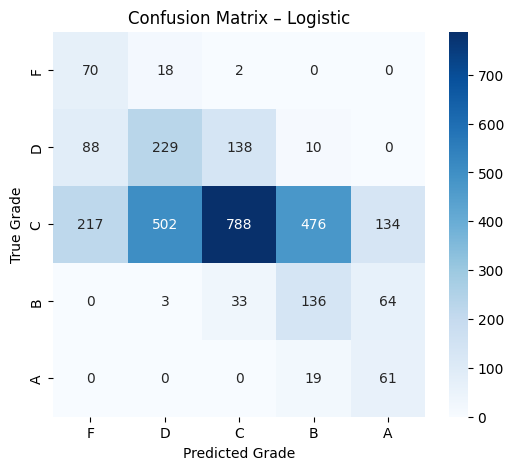


Decision Tree
Accuracy: 0.570281124497992
              precision    recall  f1-score   support

           0       0.20      0.18      0.19        90
           1       0.23      0.24      0.24       465
           2       0.72      0.72      0.72      2117
           3       0.18      0.17      0.18       236
           4       0.21      0.21      0.21        80

    accuracy                           0.57      2988
   macro avg       0.31      0.30      0.31      2988
weighted avg       0.57      0.57      0.57      2988



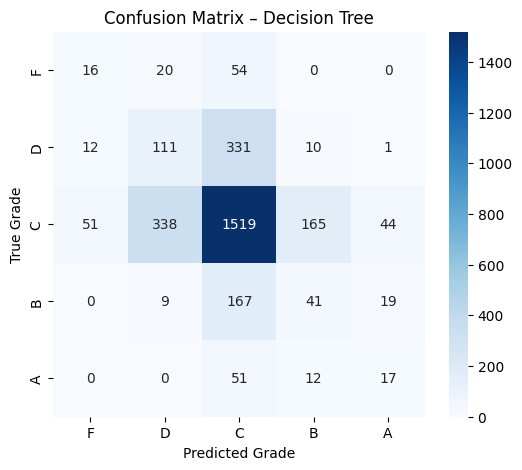


Random Forest
Accuracy: 0.7008032128514057
              precision    recall  f1-score   support

           0       0.34      0.26      0.29        90
           1       0.38      0.03      0.05       465
           2       0.72      0.97      0.82      2117
           3       0.33      0.00      0.01       236
           4       0.31      0.06      0.10        80

    accuracy                           0.70      2988
   macro avg       0.42      0.26      0.26      2988
weighted avg       0.61      0.70      0.60      2988



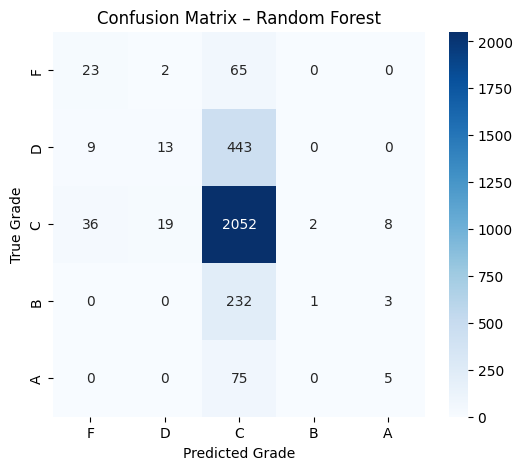


Gradient Boosting
Accuracy: 0.7048192771084337
              precision    recall  f1-score   support

           0       0.43      0.11      0.18        90
           1       0.33      0.00      0.01       465
           2       0.71      0.99      0.83      2117
           3       0.00      0.00      0.00       236
           4       0.29      0.06      0.10        80

    accuracy                           0.70      2988
   macro avg       0.35      0.23      0.22      2988
weighted avg       0.58      0.70      0.59      2988



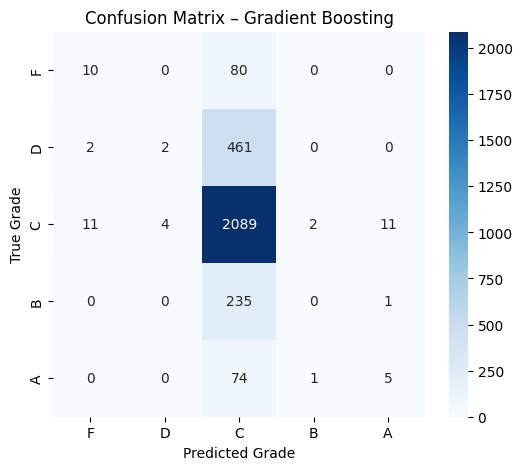


SVM
Accuracy: 0.4186746987951807
              precision    recall  f1-score   support

           0       0.22      0.56      0.32        90
           1       0.28      0.66      0.39       465
           2       0.82      0.34      0.48      2117
           3       0.22      0.63      0.33       236
           4       0.25      0.41      0.31        80

    accuracy                           0.42      2988
   macro avg       0.36      0.52      0.37      2988
weighted avg       0.66      0.42      0.44      2988



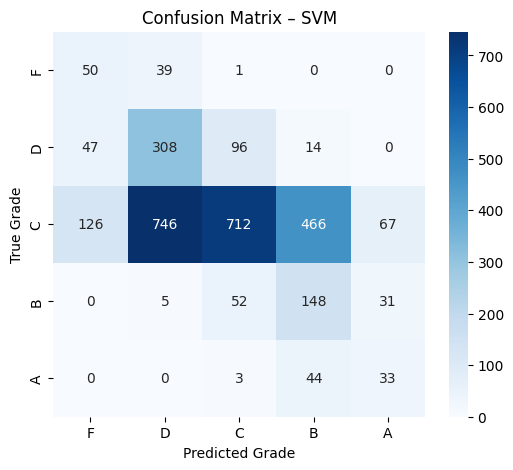

In [19]:
multi_models = {
    "Logistic": LogisticRegression(
        max_iter=3000, class_weight='balanced'
    ),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=15, class_weight='balanced'
    ),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(class_weight='balanced')
}

# Create a reverse mapping for grade labels
reverse_grade_mapping = {v: k for k, v in grade_mapping.items()}
sorted_grade_labels = [reverse_grade_mapping[i] for i in sorted(y_val_multi.unique())]

for name, model in multi_models.items():
    model.fit(X_train, y_train_multi)
    pred = model.predict(X_val)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_val_multi, pred))
    print(classification_report(y_val_multi, pred))

    # =========================
    # Confusion Matrix (Multi-class)
    # =========================
    cm = confusion_matrix(y_val_multi, pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=sorted_grade_labels,
        yticklabels=sorted_grade_labels
    )
    plt.xlabel("Predicted Grade")
    plt.ylabel("True Grade")
    plt.title(f"Confusion Matrix – {name}")
    plt.show()

##Out Of Scope(For Streamlit)

In [20]:
from joblib import dump
from sklearn.preprocessing import StandardScaler

features = [
    'midterm_score',
    'quiz_avg_score',
    'assignment_submission_rate',
    'lecture_attendance_rate'
]

X = df[features]
y_reg = df['final_score']
y_bin = df['pass_fail']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train_reg, y_test_reg, y_train_bin, y_test_bin = train_test_split(
    X_scaled, y_reg, y_bin,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)


In [21]:
dump(scaler, "scaler.pkl")


['scaler.pkl']

In [22]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor

reg_models = {
    "ridge": Ridge(alpha=1.0),
    "lasso": Lasso(alpha=0.01),
    "gbr": GradientBoostingRegressor(random_state=42)
}

for name, model in reg_models.items():
    model.fit(X_train, y_train_reg)
    dump(model, f"{name}_final_score.pkl")


In [23]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=12, weights='distance')
knn.fit(X_train, y_train_bin)
dump(knn, "knn_pass_fail.pkl")


['knn_pass_fail.pkl']

In [24]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train, y_train_bin)

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_sm, y_sm)
dump(rf, "rf_pass_fail.pkl")

svm = SVC(probability=True, class_weight='balanced', random_state=42)
svm.fit(X_sm, y_sm)
dump(svm, "svm_pass_fail.pkl")


['svm_pass_fail.pkl']